# **Test d'intégration du loader/Module/InfoNCELoss pour la phase patient-wise-learning**

In [2]:
%load_ext autoreload
%autoreload 2
from gbmhackathon.training.patientwise import *
from gbmhackathon.models.mme import MultiModalEncoder
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss
from gbmhackathon.s3_loader import load_s3

from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

# To investigate gradients
from torchviz import make_dot

import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
name_emb_dict = {"hne":"2025-03-22_12-27_phikon_emb_V1.pkl",
# "spatial":"2025-03-23_18-32_spatial_emb_V1.pkl", #Pour l'instant problm avec le spatial = pas dimensions constantes
"clinical":"2025-03-30_14-23_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [4]:
dataset = PatientLearningDataset(name_emb_dict, pkl_storage_folder)
BATCH_SIZE = 16
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_patient_wise)

In [5]:
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient]
batch_all = collate_patient_wise(batch_all)

## Pour la loss, il nous faut un dictionnaire qui associe chaque patient à un ID
On fait bien attention à indiquer les rechutes comme le même patient

In [6]:
missing_mods = load_s3("s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/missing_mod_per_samples.pkl")

In [7]:
all_ids = list(missing_mods.keys())
patient_map = {key: i for key, i in zip(all_ids, [k for k in range(1,len(all_ids)+1)])}
for patient_id, idx in patient_map.items():
    if patient_id.endswith('b'): # pour les rechutes on met le même index que le sample original
        patient_map[patient_id] = idx - 1
patient_map

{'HK_G_001a': 1,
 'HK_G_002a': 2,
 'HK_G_003a': 3,
 'HK_G_004a': 4,
 'HK_G_005a': 5,
 'HK_G_006a': 6,
 'HK_G_007a': 7,
 'HK_G_008a': 8,
 'HK_G_009a': 9,
 'HK_G_010a': 10,
 'HK_G_011a': 11,
 'HK_G_012a': 12,
 'HK_G_013a': 13,
 'HK_G_014a': 14,
 'HK_G_015a': 15,
 'HK_G_016a': 16,
 'HK_G_017b': 16,
 'HK_G_018a': 18,
 'HK_G_019a': 19,
 'HK_G_020a': 20,
 'HK_G_021a': 21,
 'HK_G_022a': 22,
 'HK_G_023a': 23,
 'HK_G_024a': 24,
 'HK_G_025a': 25,
 'HK_G_026a': 26,
 'HK_G_027a': 27,
 'HK_G_028a': 28,
 'HK_G_029b': 28,
 'HK_G_030a': 30,
 'HK_G_031a': 31,
 'HK_G_032a': 32,
 'HK_G_033a': 33,
 'HK_G_034a': 34,
 'HK_G_035a': 35,
 'HK_G_036b': 35,
 'HK_G_037a': 37,
 'HK_G_038a': 38,
 'HK_G_039a': 39,
 'HK_G_040a': 40,
 'HK_G_041a': 41,
 'HK_G_042a': 42,
 'HK_G_043a': 43,
 'HK_G_044b': 43,
 'HK_G_045a': 45,
 'HK_G_046a': 46,
 'HK_G_047a': 47,
 'HK_G_048a': 48,
 'HK_G_049a': 49,
 'HK_G_050a': 50,
 'HK_G_051a': 51,
 'HK_G_052a': 52,
 'HK_G_053a': 53,
 'HK_G_054a': 54,
 'HK_G_055a': 55,
 'HK_G_056a': 56,
 

## Voir à quoi ressemble l'output du loader

In [8]:
toy_batch = next(iter(dataloader))
toy_batch

(['HK_G_101a',
  'HK_G_099a',
  'HK_G_102a',
  'HK_G_062a',
  'HK_G_065a',
  'HK_G_022a',
  'HK_G_075a',
  'HK_G_078a',
  'HK_G_053a',
  'HK_G_019a',
  'HK_G_072a',
  'HK_G_039a',
  'HK_G_016a',
  'HK_G_088a',
  'HK_G_054a',
  'HK_G_067a'],
 ['hne', 'clinical', 'wes'],
 {'hne': tensor([[[-0.3025, -0.3663,  0.1272,  ..., -0.1188, -0.2323, -0.1110]],
  
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
  
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
  
          ...,
  
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
  
          [[-0.1688, -0.6047,  0.2746,  ...,  0.0203,  0.2791, -0.3571]],
  
          [[ 0.0242, -0.1675,  0.2995,  ..., -0.0592, -0.0973, -0.0150]]]),
  'clinical': tensor([[ 3.8377e-01,  8.1690e-01, -2.0376e-01,  4.8591e-01,  1.7447e-01,
            5.4749e-02, -8.2147e-02,  2.0958e-01, -2.4535e-02, -8.6816e-02,
           -2.9042e-01,  3.9335e-01],
          [-1.5425e+00,  2.2406e+00, -1.62

In [9]:
raw_emb = toy_batch[2]
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())

hne torch.Size([16, 1, 1024])
clinical torch.Size([16, 12])
wes torch.Size([16, 1790])


# Pour instantier le MultiModalEncoder
Il faut des config pour chaque modalité, par simplicité on va définir une coquille de base et simplement ajouter la bonne dimension en entrée

In [10]:
base_config = {"layers": [128,64],
        "dropout": 0.5,
        "act_fn":torch.nn.ReLU,
        "norm_layer":None}

def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

hne_cfg = adapt_base_config(base_config, 1024)
clinical_cfg = adapt_base_config(base_config, 12)
wes_cfg = adapt_base_config(base_config, 1790)

In [11]:
mme_cfg = {"hne_cfg":hne_cfg, "clinical_cfg":clinical_cfg, "wes_cfg":wes_cfg}

In [12]:
def check_inf(tensor):
    return torch.isinf(tensor).sum() != 0
    
def check_nan(tensor):
    return torch.isnan(tensor).sum() != 0

def check(tensor):
    return check_inf(tensor) or check_nan(tensor)

def show_tensor(tensor, mode='grad'):
    plt.figure(figsize=(15,15))
    if mode == 'grad':
        if len(tensor.numpy().shape) == 1:
            plt.imshow(tensor.numpy().reshape(1,-1))
        else:
            plt.imshow(tensor.numpy())
        title = f"Average layer grad: {tensor.mean()}"
    else:
        if len(tensor.detach().numpy().shape) == 1:
            plt.imshow(tensor.detach().numpy().reshape(1,-1))
        else:
            plt.imshow(tensor.detach().numpy())
        title = f"Average layer output: {tensor.mean()}\nRatio of 0 : {(tensor == 0).sum() / tensor.size(0)}"
    plt.colorbar()
    plt.tight_layout()
    plt.title(title)
    plt.show()
    
def run_debug(EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8):
    EPOCHFLAG = 0
    problematic_batch_patient_ids = []
    # 1. Define model encoders + loss
    mme = MultiModalEncoder(**mme_cfg)
    loss_fn = RegularizedInfoNCELoss(list(name_emb_dict.keys()),
                                     patient_map, 
                                     temperature=temp, 
                                     similarity=sim, 
                                     use_all_positives=False,
                                     alpha=alpha,
                                     bound=bound,
                                     beta=beta,
                                     nce_eps=nce_eps,
                                     reg_eps=reg_eps)
    optimizer = Adam(
        mme.parameters(),
        lr=1e-3,
    )
    # print(dict(mme.named_parameters()))
    # 2. Training loop
    EPOCH_LOSSES = []
    for epoch in range(EPOCHS):
        epoch_loss = []
        for i, batch in enumerate(dataloader):
            # batch = (X_dict, patient_ids, available_modalities)
            patient_ids, modalities, X_dict, avail_mods = batch
            # print("patient_ids:", patient_ids)
            # print("modalities:", modalities)
            # print("X_dict:", X_dict)
            # print("avail_mods:", avail_mods)
        
            # print(X_dict)
            encoded = mme(X_dict)
            NANFLAG = {}
            for mod in X_dict.keys():
                if check(X_dict[mod]):
                    # print("INPUT", X_dict[mod])
                    NANFLAG[mod] = 1
                    
                for key, tensor in dict(mme.wes_net.named_parameters()).items():
                    if check(tensor):
                        # print("WEIGHTS", dict(mme.wes_net.named_parameters()))
                        NANFLAG[mod] = 1
                        break
                if check(encoded[mod]):
                    # print("ENCODED", encoded[mod])
                    NANFLAG[mod] = 1
            if 1 in list(NANFLAG.values()):
                # print("Batch patient ids:", patient_ids)
                problematic_batch_patient_ids.append(patient_ids)
                EPOCHFLAG = 1
                break
                # raise ValueError(f"Found NANs in modality {[key for key in NANFLAG.keys() if NANFLAG[key] == 1]}")
            else:
                # # 2b. Pack into expected batch for loss
                loss_batch = (encoded, patient_ids, avail_mods)
                
                # # 2c. Compute loss & backward
                loss = loss_fn(loss_batch)
                optimizer.zero_grad()
                # dot = make_dot(loss, params=dict(mme.named_parameters()), show_attrs=True, show_saved=True)
                # try:
                #     dot.view()
                # except:
                #     pass
                loss.backward()
                # for mod in X_dict.keys():
                #     param_dict = dict(mme.modality_net_map[mod].named_parameters())
                #     tensor = param_dict[list(param_dict.keys())[0]] # 1st layer parameters
                #     print(f"{key} GRADS:", tensor.grad)
                #     show_tensor(tensor.grad)
                #     print(f"Average 1st layer grad for {mod.upper()}: {tensor.mean()}")
                optimizer.step()
                epoch_loss.append(loss.item())
                # print(f"Batch {i} loss: {loss.item():.4f}")
        print(f"Epoch {epoch} loss: {np.mean(epoch_loss):.4f}".upper())
        if EPOCHFLAG == 1:
            print("BREAK")
            break
        EPOCH_LOSSES.append(np.mean(epoch_loss))
    return EPOCH_LOSSES, mme

In [13]:
# problematic_patient_ids = []
# for run in range(10): 
#     print(f'RUN {run}')
#     problematic_patient_ids += run_debug(0.07, "original")

In [14]:
# problematic_patient_ids

In [15]:
# all_problematic_ids = []
# for id_list in problematic_patient_ids:
#     all_problematic_ids += id_list
# unique_ids = np.unique(all_problematic_ids)

# uid_presence = {uid:0 for uid in unique_ids}
# for uid in unique_ids:
#     for batch in problematic_patient_ids:
#         if uid in batch:
#             uid_presence[uid] += 1
# uid_presence

### Pas de patients commun à tous les batchs problématiques

### Les exponentielles montent forts => Gradient chelous: Apparemment courant pour la InfoNCELoss, il faut à tout prix tune le scaling parameter
To adress this, we need to find a good temperature. We also can try another similarity definition: cosine.

In [16]:
def show_weights(module: torch.nn.Module):
    """
    Plots histograms of all named parameter weights in the given PyTorch module.
    
    Args:
        module (nn.Module): The PyTorch module whose parameters will be visualized.
    """
    # Collect parameters
    params = list(module.named_parameters())
    num_params = len(params)
    if num_params == 0:
        print("Module has no parameters to show.")
        return
    
    # Determine subplot grid size
    cols = min(4, num_params)
    rows = (num_params + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten() if num_params > 1 else [axes]
    
    for idx, (name, param) in enumerate(params):
        data = param.detach().cpu().numpy().ravel()
        axes[idx].hist(data, bins=50)
        axes[idx].set_title(name)
        axes[idx].set_xlabel("Weight value")
        axes[idx].set_ylabel("Frequency")
    
    # Hide any unused subplots
    for j in range(idx+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
def log_and_plot_runs(RUNS, run_debug, EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8, show_w=False, show_out_all=True):
    """
    Executes `run_debug` multiple times, logs final_loss per epoch for each run,
    and then plots all runs plus the average curve in bold.
    
    Args:
        RUNS (int): Number of runs to perform.
        EPOCHS (int): Number of epochs per run.
        run_debug (callable): Function with signature run_debug(EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8) 
                              returning a list/array of losses per epoch and the module.
        temp: Temperature parameter passed to run_debug.
        sim: Similarity parameter passed to run_debug.
    """
    # Store losses for all runs
    all_runs_losses = np.zeros((RUNS, EPOCHS))
    
    for run in range(RUNS):
        print(f"\nRUN {run}:")
        losses, mme = run_debug(EPOCHS, temp, sim, alpha=alpha, bound=bound, beta=beta, nce_eps=nce_eps, reg_eps=reg_eps)  # expects length EPOCHS
        all_runs_losses[run:] = losses
        if show_w:
            show_weights(mme)
        if show_out_all:
            out_dict = mme(batch_all[2])
            for pid in range(5): # 5 premiers
                show_tensor(torch.cat([out_dict[mod][pid].view(-1) for mod in out_dict.keys()], dim=0), mode='out')
    # Compute average curve
    avg_curve = all_runs_losses.mean(axis=0)
    
    # Plotting
    plt.figure(figsize=(8, 5))
    
    # Plot each run
    for run in range(RUNS):
        plt.plot(range(1, EPOCHS+1), all_runs_losses[run], linewidth=1, c='grey', label=f'Run {run+1}')
    
    # Plot average in bold
    plt.plot(range(1, EPOCHS+1), avg_curve, linewidth=3, label='Average', zorder=10)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves for Each Run with Average')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
log_and_plot_runs(1, run_debug, 50, 0.02, "nt-xent", alpha=0.1, bound=-10, show_out_all=True)

In [ ]:
log_and_plot_runs(1, run_debug, 50, 100, "original", alpha=0.01, bound=-10, show_out_all=True)


RUN 0:
tensor([0.4775, 0.5400, 0.5137])
tensor([0.4541, 0.5205, 0.4863])
tensor([0.4863, 0.5186, 0.4824])
tensor([0.4951, 0.5020, 0.4766])
tensor([0.4902, 0.5078, 0.4658])
tensor([0.5117, 0.5205, 0.4717])
tensor([0.5068, 0.5273, 0.4727])
tensor([0.4453, 0.4766, 0.4531])
EPOCH 0 LOSS: -1.9579
tensor([0.4365, 0.5186, 0.4492])
tensor([0.4658, 0.5127, 0.5010])
tensor([0.4287, 0.4961, 0.4609])
tensor([0.4355, 0.4814, 0.4551])
tensor([0.4297, 0.4795, 0.4629])
tensor([0.4189, 0.4941, 0.4521])
tensor([0.4150, 0.4746, 0.4717])
tensor([0.4062, 0.4766, 0.4609])
EPOCH 1 LOSS: -5.1671
tensor([0.4375, 0.4775, 0.4512])
tensor([0.4189, 0.4805, 0.4512])
tensor([0.4346, 0.4941, 0.4365])
tensor([0.4141, 0.4824, 0.4453])
tensor([0.4326, 0.4893, 0.4219])
tensor([0.4512, 0.5068, 0.4355])
tensor([0.4307, 0.4707, 0.4355])
tensor([0.4062, 0.4688, 0.4609])
EPOCH 2 LOSS: -5.7948
tensor([0.3896, 0.4688, 0.4395])
tensor([0.4365, 0.4434, 0.4434])
tensor([0.4248, 0.4824, 0.4189])
tensor([0.4395, 0.4766, 0.4443])
te

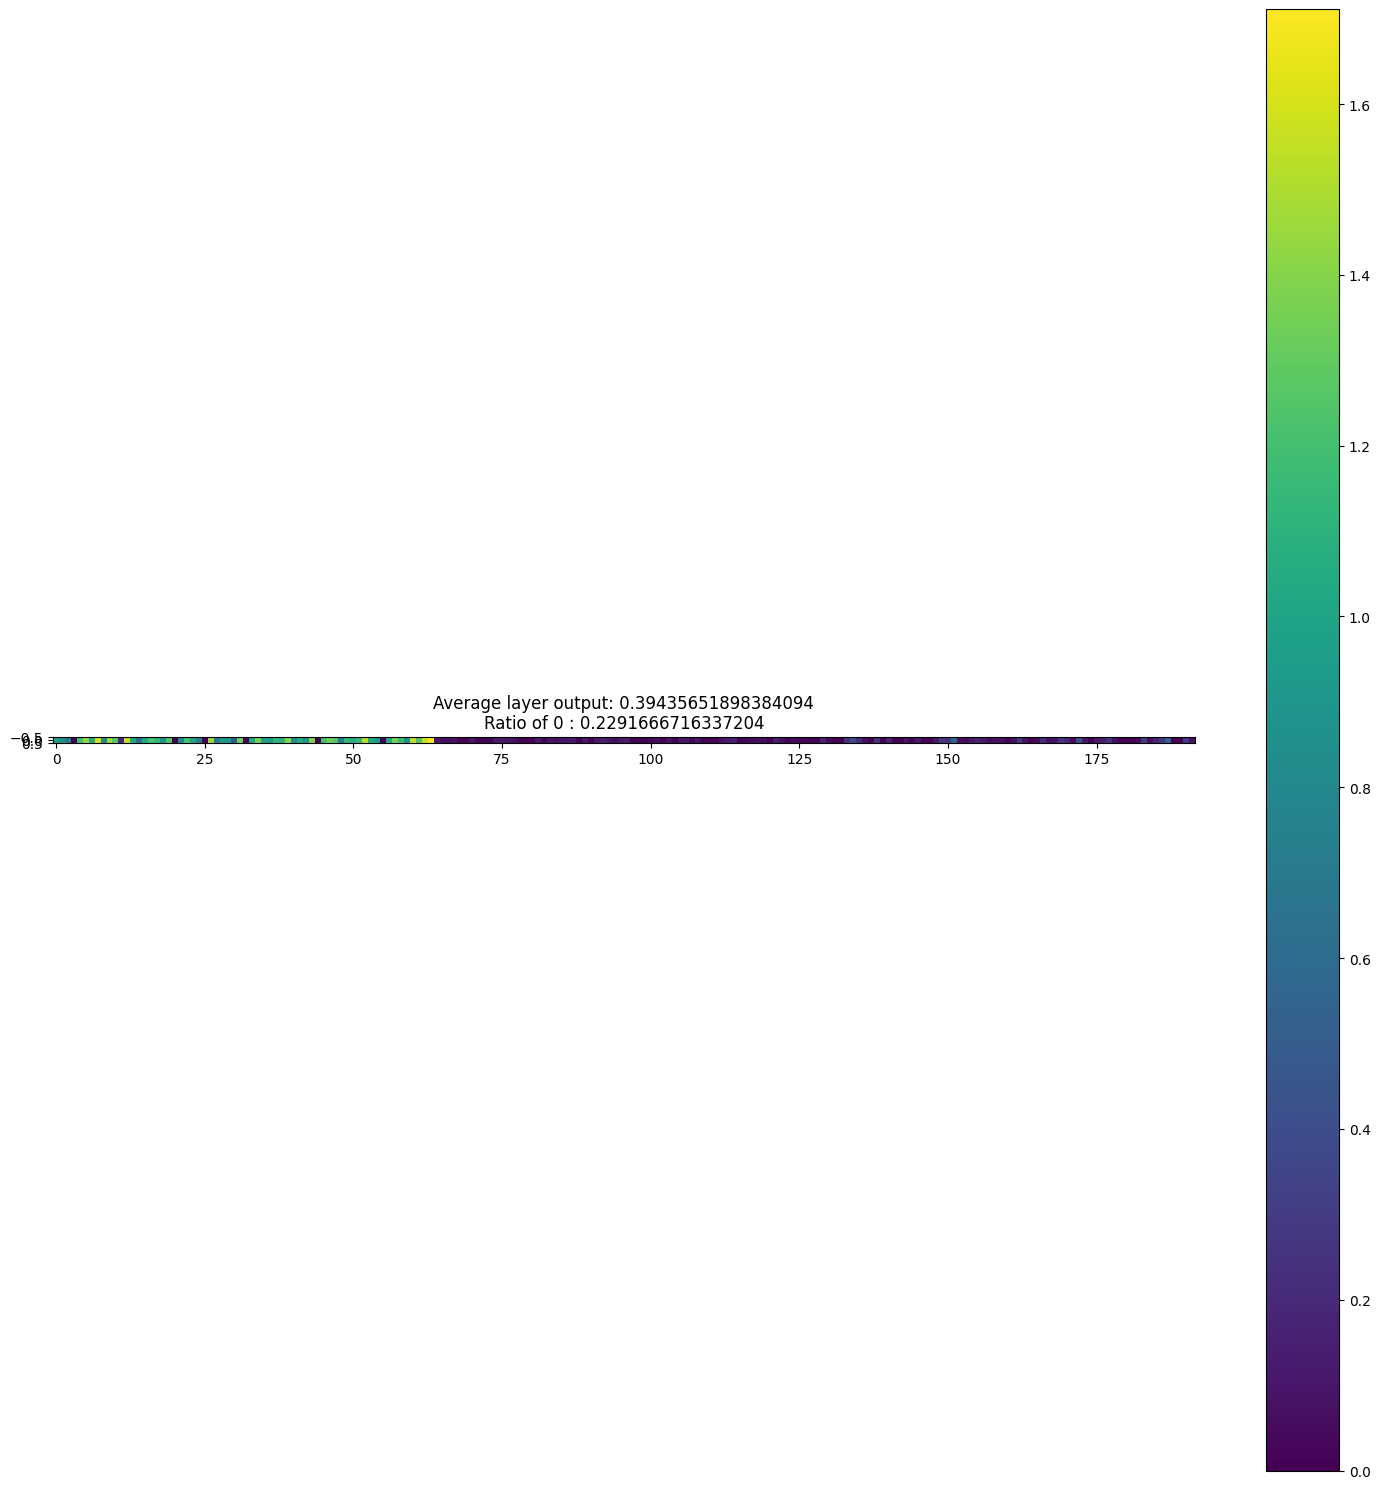

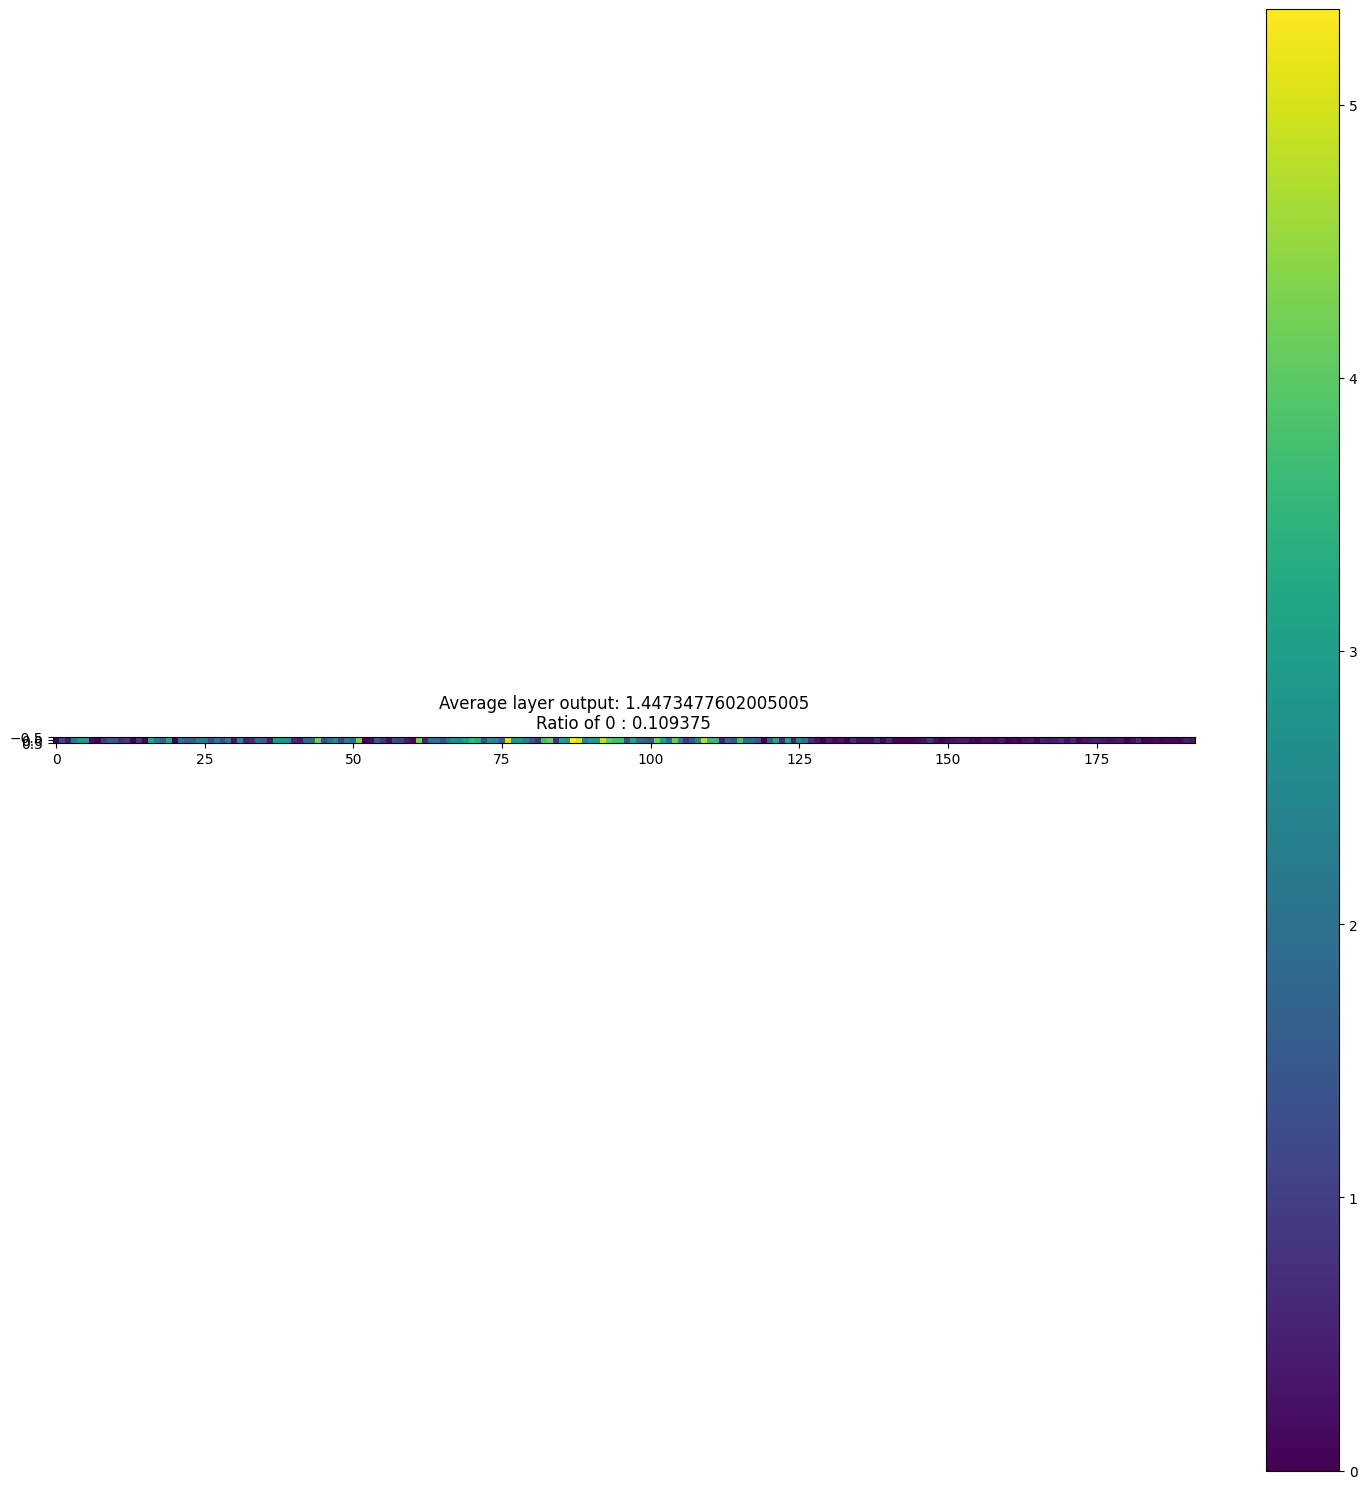

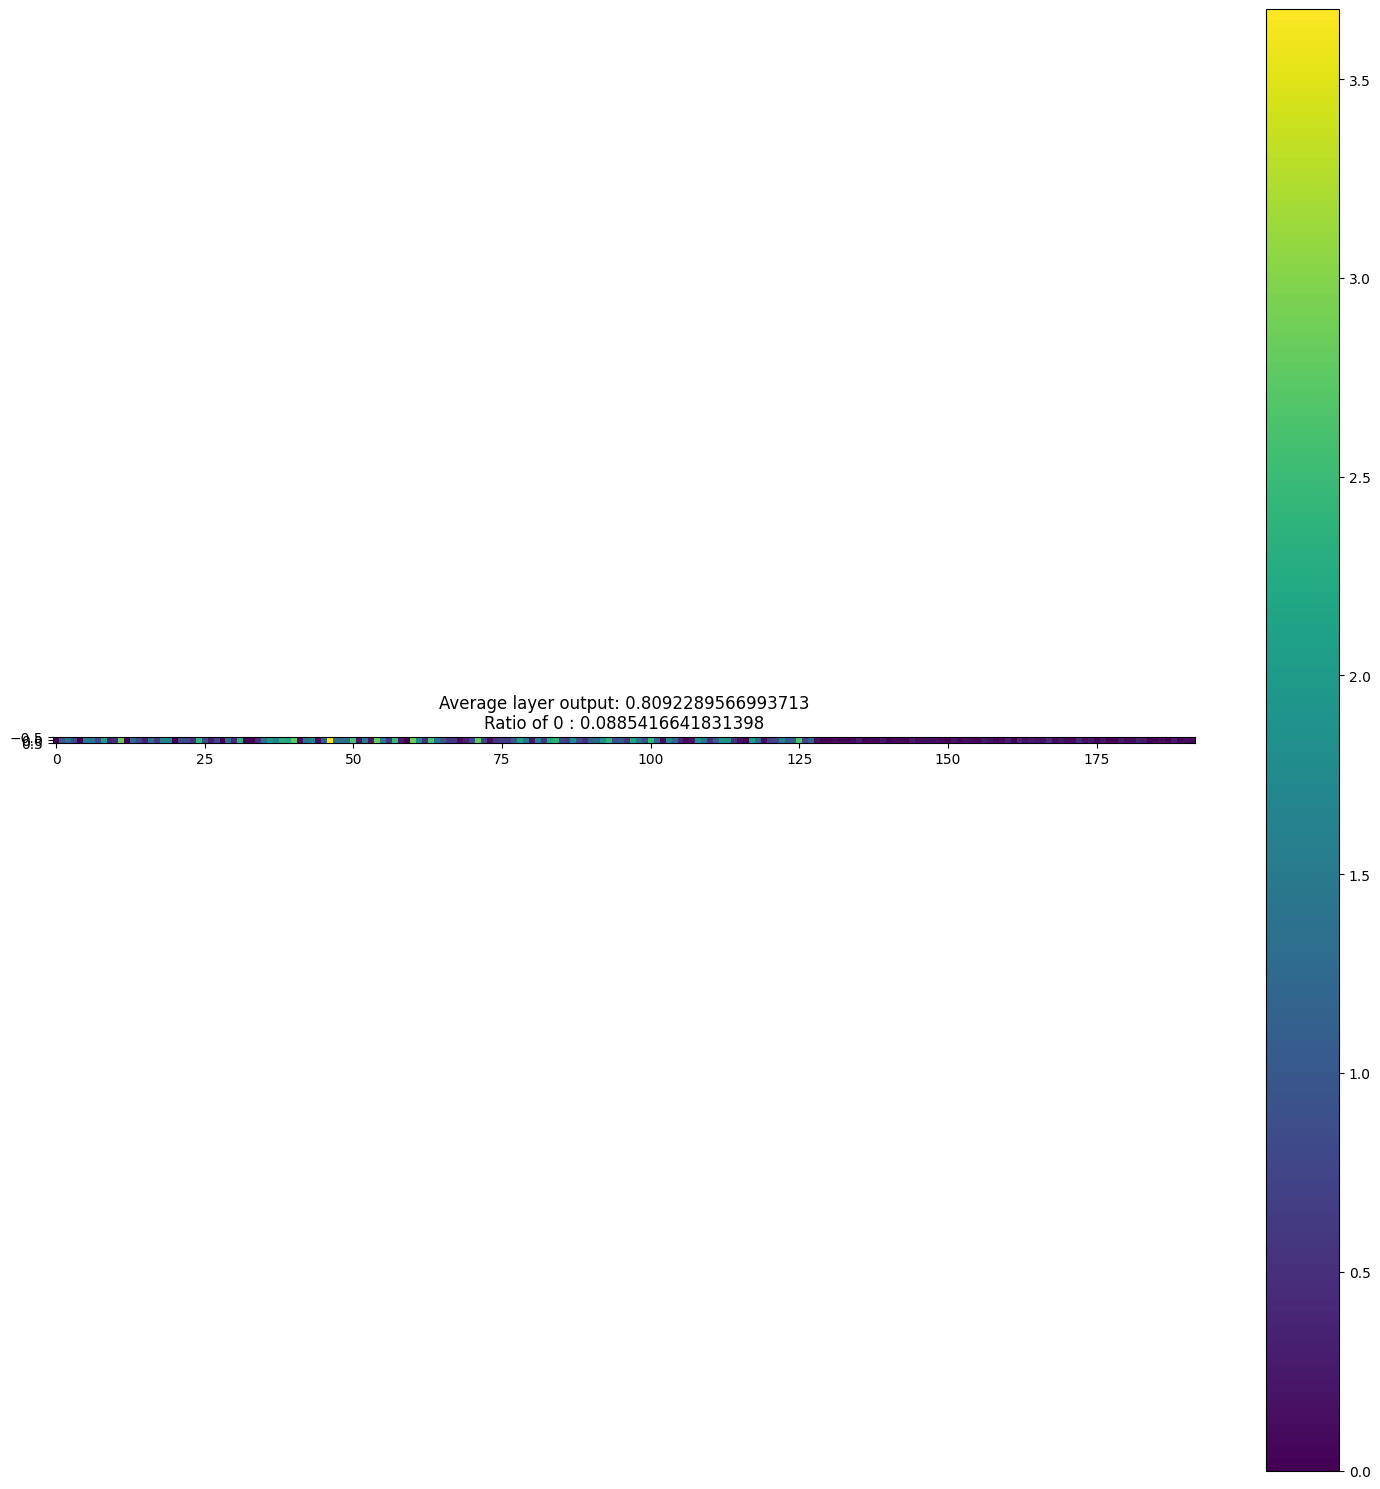

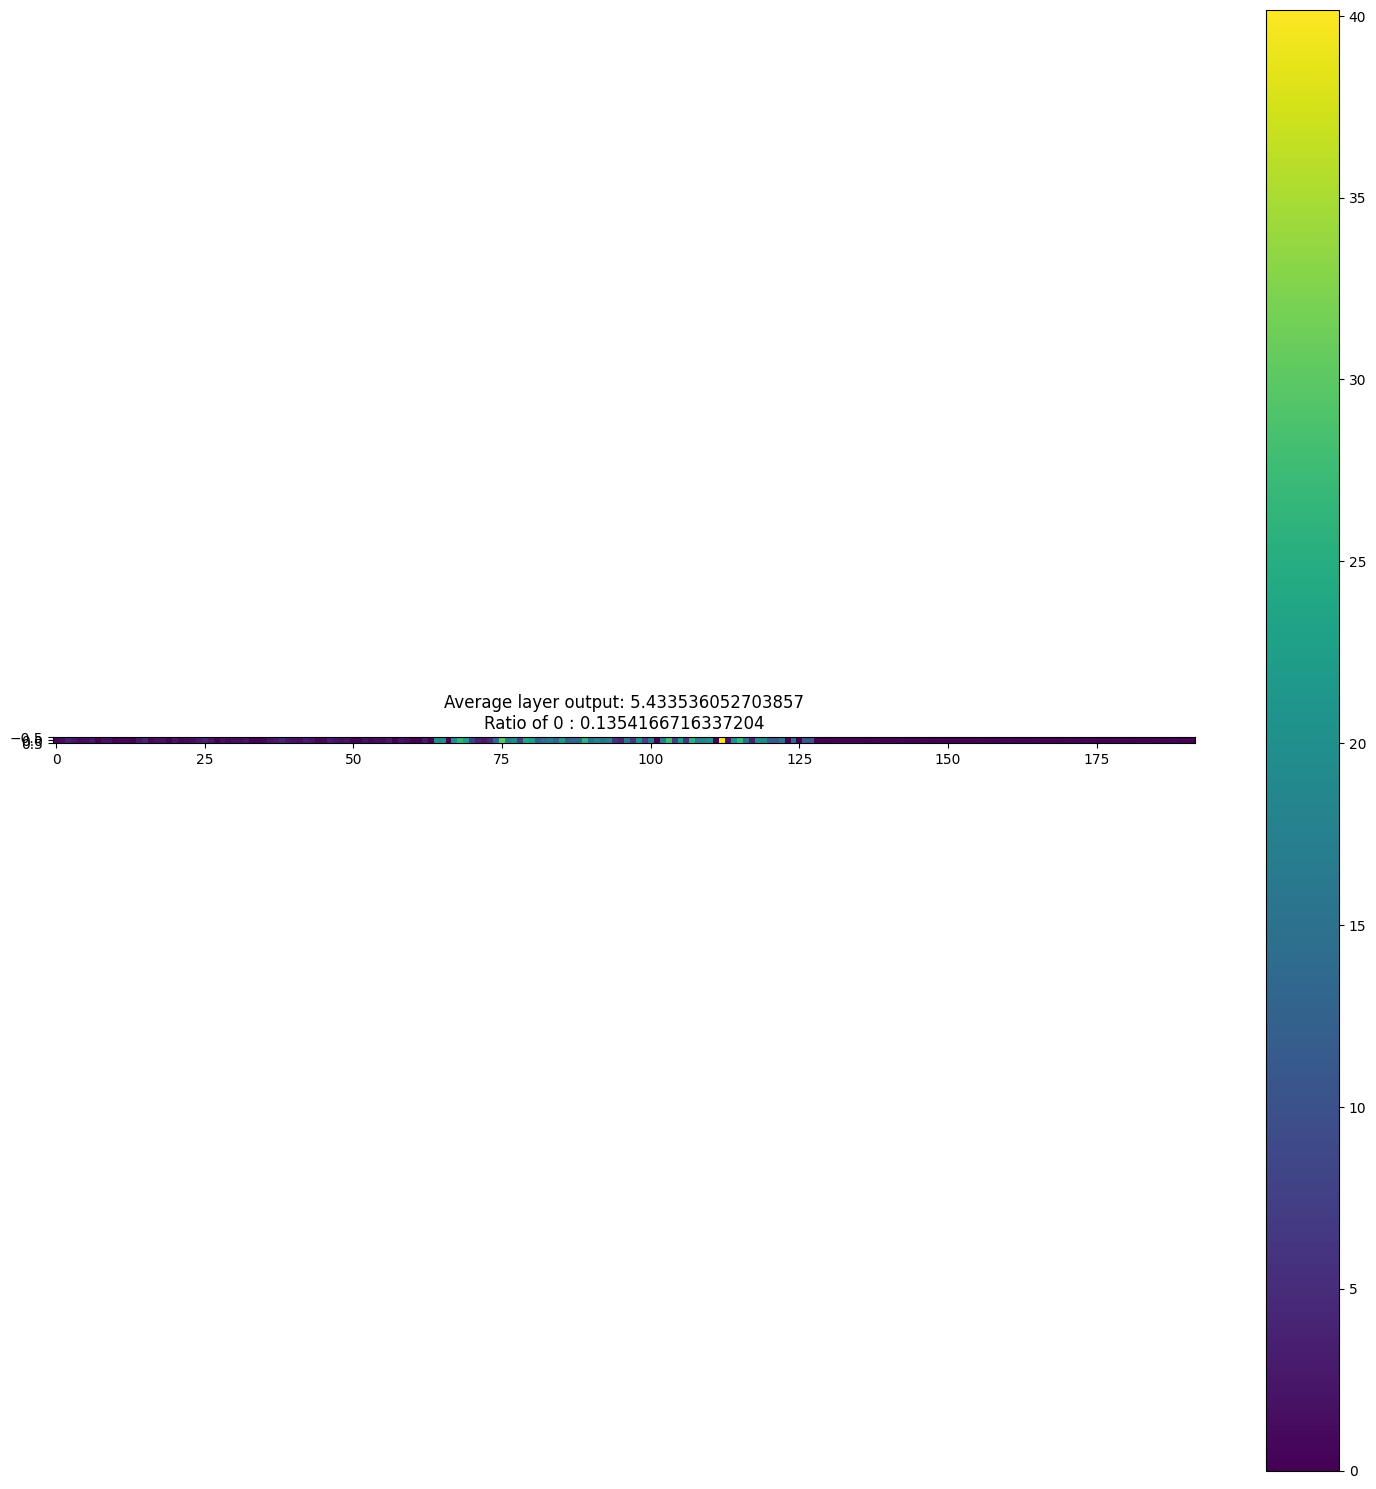

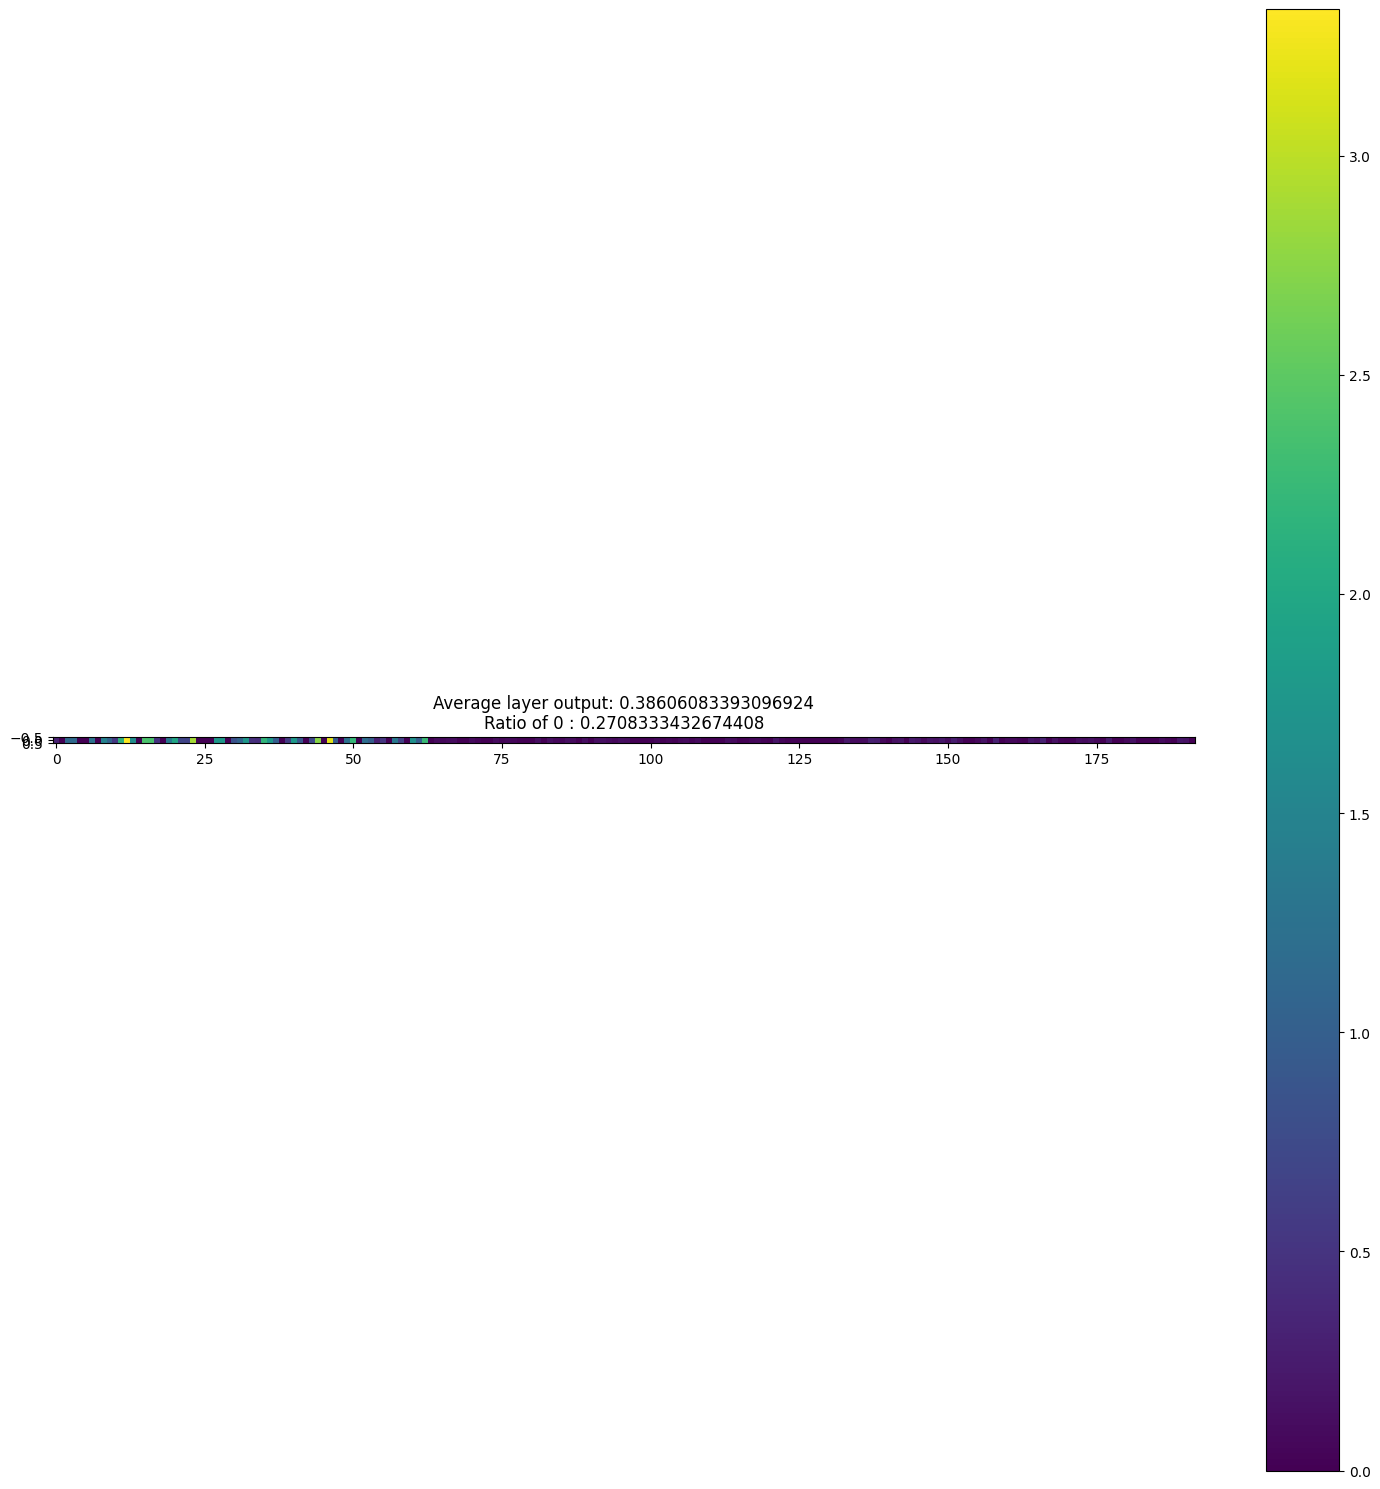

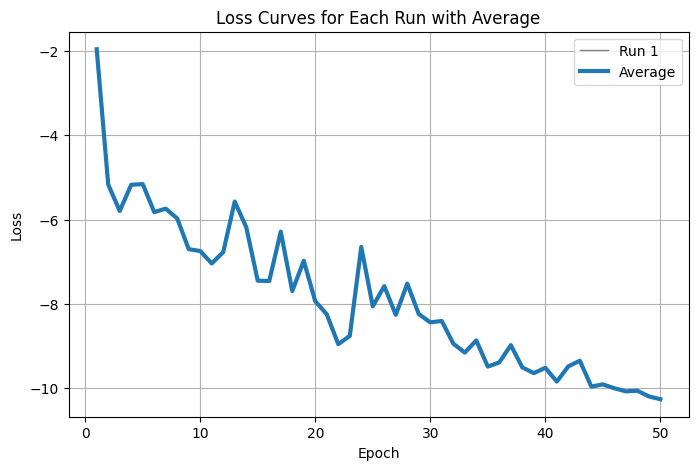

In [23]:
log_and_plot_runs(1, run_debug, 50, 0.02, "nt-xent", alpha=0.1, beta=0.1, show_out_all=True)